# Library loaded.

In [45]:
import pandas as pd
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import time
import os
from bs4 import BeautifulSoup, XMLParsedAsHTMLWarning
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import spacy
import re
from sklearn.feature_extraction.text import TfidfVectorizer
from collections import defaultdict
import matplotlib.colors as mcolors

warnings.filterwarnings('ignore')
warnings.filterwarnings("ignore", category=XMLParsedAsHTMLWarning) # Ignore unnecessary warnings from BeautifulSoup

nltk.download('stopwords')
nltk.download('wordnet') 

nlp = spacy.load("en_core_web_sm", disable=["parser", "senter"]) # model for proper noun detection

print("Libraries loaded successfully.")

[nltk_data] Downloading package stopwords to /home/jaee/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /home/jaee/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


Libraries loaded successfully.


## Data Loaded

In [46]:
# -------------------------------------------------------------------
# UPDATE THIS PATH to point to your full ~6000 page dataset
# -------------------------------------------------------------------
DATA_PATH = "../data/english_pages_metadata_clean_with_labels.csv"

df = pd.read_csv(DATA_PATH, encoding='utf-8-sig')
df['full_text'] = df['full_text'].fillna('').astype(str)

print(f"Loaded {len(df)} pages")
print(f"Columns: {list(df.columns)}")

# Text length statistics
print(f"\nText length statistics (characters):")
print(df['full_text'].str.len().describe())

df.head(3)

Loaded 596 pages
Columns: ['page_id', 'assigned_to', 'manual_label', 'manual_label_clean', 'manual_label_final', 'full_text', '_merge']

Text length statistics (characters):
count      596.000000
mean      6535.971477
std       9110.613565
min        294.000000
25%       1748.500000
50%       3446.500000
75%       7771.000000
max      75582.000000
Name: full_text, dtype: float64


,page_id,assigned_to,manual_label,manual_label_clean,manual_label_final,full_text,_merge
0,655.0,Vinay Varshigan Sivakumar Jayalakshmi,ecommerce,ECOMMERCE,ECOMMERCE,Fall arrest and work positioning harness – All...,both
1,656.0,Vinay Varshigan Sivakumar Jayalakshmi,blog,BLOG,BLOG,Vermont Mountain Eats: Jay Peak - All Mountain...,both
2,657.0,Vinay Varshigan Sivakumar Jayalakshmi,news,NEWS,NEWS,05/18/2020 Booking Report for Bulloch County -...,both


## Label Checked

In [48]:
# Load labels if available (for downstream evaluation in Notebook 2)
LABELS_PATH = "../data/english_pages_metadata_clean_with_labels.csv"

if os.path.exists(LABELS_PATH):
    labels_df = pd.read_csv(LABELS_PATH)
    labels_subset = labels_df[['page_id', 'manual_label_final']].copy()
    df = pd.merge(df, labels_subset, on='page_id', how='left')
    print(f"Labels merged. Distribution:")
    print(df["manual_label_final"].value_counts())
else:
    print(f"Labels file not found. Proceeding without labels.")

Labels merged. Distribution:
manual_label_final
OTHER               158
BLOG                123
ECOMMERCE           114
EDUCATION            61
NEWS                 47
FORUM/DISCUSSION     46
TECHNICAL            34
GOVERNMENT           13
Name: count, dtype: int64


## Preprocessing

In [50]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess(text):
    # Remove \n, \r, \t
    text = re.sub(r'[\n\r\t]+', ' ', text)
    
    # Remove URLs and emails
    text = re.sub(r'(?:https?://|ftp://|www\.)\S+|mailto:\S+|tel:\S+', '', text)
    text = re.sub(r'\b[a-z0-9._%+-]+@[a-z0-9.-]+\.[a-z]{2,}\b', '', text)

    # Remove HTML tags like <body>, but first remove script/style content
    soup = BeautifulSoup(text, 'html.parser')
    for tag in soup(['script', 'style', 'noscript']):
        tag.decompose()
    text = soup.get_text(separator=' ')

    # Build proper noun set
    # proper_nouns = build_proper_noun_set_spacy(text)

    # Split camelCases
    text = re.sub(r'([a-z])([A-Z])', r'\1 \2', text)

    # Remove proper nouns
    # text = ' '.join(w for w in text.split() if w.lower() not in proper_nouns)

    # Remove separators such as _, -, /, |, ...
    text = re.sub(r'[_\-/|]', ' ', text)
    
    # Lowercase
    text = text.lower()
        
    # Remove non-ASCII characters
    text = re.sub(r'[^\x00-\x7F]', ' ', text)

    # Normalize repeated characters like 'yessss', 'noooooo', ...
    text = re.sub(r'(.)\1{2,}', r'\1\1', text)
    
    # Keep only letters and spaces
    text = re.sub(r'[^a-z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip() # remove multiple spaces

    # Tokenize and filter with stop words and lemmatization
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(t) for t in tokens
              if len(t) >= 3
              and len(t) <= 20 # Remove very long words
              and t not in stop_words] # Keep 3 letter words like api, cpu, ...
    
    return tokens

## Input data preparation

In [51]:
# Prepare text list used by all models
texts = df['full_text'].apply(preprocess).tolist()
print(texts[0][:100])
print(f"Prepared {len(texts)} documents for embedding.")

['fall', 'arrest', 'work', 'positioning', 'harness', 'allied', 'safety', 'equipment', 'pvt', 'ltd', 'skip', 'content', 'sport', 'professional', 'search', 'search', 'enquire', 'activity', 'industry', 'rope', 'access', 'confined', 'space', 'facade', 'cleaning', 'wind', 'mill', 'bird', 'netting', 'tree', 'care', 'energy', 'network', 'framing', 'roofing', 'stunt', 'stunt', 'vest', 'aerial', 'acrobatics', 'corset', 'waist', 'chest', 'strap', 'accessory', 'adventure', 'park', 'harness', 'rescue', 'building', 'rescue', 'technical', 'rescue', 'ski', 'lift', 'rescue', 'site', 'rescue', 'military', 'intervention', 'slithering', 'brand', 'industry', 'petzl', 'tractel', 'portable', 'winch', 'tracer', 'mode', 'rescue', 'hwi', 'fast', 'rope', 'rope', 'petzl', 'sterling', 'teufelberger', 'special', 'rope', 'product', 'industry', 'helmet', 'headlamp', 'harness', 'connector', 'descender', 'rope', 'clamp', 'pulley', 'anchor', 'lanyard', 'rope', 'fixed', 'line', 'fall', 'protection', 'temporary', 'line',

## all-MiniLM-L6-v2 loaded

In [52]:
from sentence_transformers import SentenceTransformer

mini_model = SentenceTransformer('all-MiniLM-L6-v2')

print(f"Model loaded: all-MiniLM-L6-v2")
print(f"Max sequence length: {mini_model.max_seq_length}")
print(f"Embedding dimension: {mini_model.get_sentence_embedding_dimension()}")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model loaded: all-MiniLM-L6-v2
Max sequence length: 256
Embedding dimension: 384


## Generate Embedding using all-MiniLM-L6-v2

In [53]:
print(f"Generating MiniLM embeddings for {len(texts)} documents...")
start_time = time.time()

mini_embeddings = mini_model.encode(
    texts,
    batch_size=64,
    show_progress_bar=True,
    normalize_embeddings=True
)

elapsed = time.time() - start_time
print(f"\nDone in {elapsed:.1f} seconds ({len(texts)/elapsed:.1f} docs/sec)")
print(f"Embedding matrix shape: {mini_embeddings.shape}")

Generating MiniLM embeddings for 596 documents...


Batches:   0%|          | 0/10 [00:00<?, ?it/s]


Done in 0.4 seconds (1699.2 docs/sec)
Embedding matrix shape: (596, 384)


## Embedding by all-MiniLM-L6-v2 saved

In [54]:
np.save('mini_embeddings.npy', mini_embeddings)
print(f"Saved mini_embeddings.npy, shape {mini_embeddings.shape}")

Saved mini_embeddings.npy, shape (596, 384)


## OpenAI text-embedding-3-small Loaded

In [55]:
from openai import OpenAI
import tiktoken
from dotenv import load_dotenv

load_dotenv()
client = OpenAI(api_key=os.environ.get("OPENAI_API_KEY"))

OPENAI_MODEL = "text-embedding-3-small"

encoding = tiktoken.get_encoding("cl100k_base")
MAX_TOKENS = 8000

print(f"OpenAI client initialized. Model: {OPENAI_MODEL}")

OpenAI client initialized. Model: text-embedding-3-small


In [56]:
print(texts[0][:100])

['fall', 'arrest', 'work', 'positioning', 'harness', 'allied', 'safety', 'equipment', 'pvt', 'ltd', 'skip', 'content', 'sport', 'professional', 'search', 'search', 'enquire', 'activity', 'industry', 'rope', 'access', 'confined', 'space', 'facade', 'cleaning', 'wind', 'mill', 'bird', 'netting', 'tree', 'care', 'energy', 'network', 'framing', 'roofing', 'stunt', 'stunt', 'vest', 'aerial', 'acrobatics', 'corset', 'waist', 'chest', 'strap', 'accessory', 'adventure', 'park', 'harness', 'rescue', 'building', 'rescue', 'technical', 'rescue', 'ski', 'lift', 'rescue', 'site', 'rescue', 'military', 'intervention', 'slithering', 'brand', 'industry', 'petzl', 'tractel', 'portable', 'winch', 'tracer', 'mode', 'rescue', 'hwi', 'fast', 'rope', 'rope', 'petzl', 'sterling', 'teufelberger', 'special', 'rope', 'product', 'industry', 'helmet', 'headlamp', 'harness', 'connector', 'descender', 'rope', 'clamp', 'pulley', 'anchor', 'lanyard', 'rope', 'fixed', 'line', 'fall', 'protection', 'temporary', 'line',

## Embedding generated by text-embedding-3-small

In [57]:
def truncate_text(text, max_tokens=MAX_TOKENS):
    """Truncate text to fit within token limit."""
    tokens = encoding.encode(text)
    if len(tokens) > max_tokens:
        return encoding.decode(tokens[:max_tokens])
    return text

def get_openai_embeddings(texts, client, model=OPENAI_MODEL, batch_size=100):
    """Generate OpenAI embeddings in batches."""
    all_embeddings = []
    for i in tqdm(range(0, len(texts), batch_size), desc="OpenAI batches"):
        batch = texts[i : i + batch_size]
        batch = [t if t.strip() else " " for t in batch]
        response = client.embeddings.create(model=model, input=batch)
        all_embeddings.extend([item.embedding for item in response.data])
    return np.array(all_embeddings)

texts_strings = [" ".join(t) for t in texts]
oai_texts = [truncate_text(t) for t in texts_strings]

print(f"Generating OpenAI embeddings for {len(oai_texts)} documents...")
print(f"Estimated cost: ~${len(oai_texts) * 500 * 0.02 / 1_000_000:.2f}")
start_time = time.time()

oai_embeddings = get_openai_embeddings(oai_texts, client)

elapsed = time.time() - start_time
print(f"\nDone in {elapsed:.1f} seconds")
print(f"Embedding matrix shape: {oai_embeddings.shape}")

Generating OpenAI embeddings for 596 documents...
Estimated cost: ~$0.01


OpenAI batches: 100%|██████████| 6/6 [00:07<00:00,  1.28s/it]


Done in 7.7 seconds
Embedding matrix shape: (596, 1536)


## Embedding by text-embedding-3-small saved

In [58]:
np.save('openai_embeddings.npy', oai_embeddings)
print(f"Saved openai_embeddings.npy, shape {oai_embeddings.shape}")

Saved openai_embeddings.npy, shape (596, 1536)


## Load bge-small-en-v1.5 model, and generate embeddings
- bge-small-en-v1.5 model has 384D, which is the same dimension as all-MiniLM-L6-v2.
- bge-small-en-v1.5 model has clustering score of about 50, while all-MiniLM-L6-v2 has about 42.
- bge-small-en-v1.5 model has MTEB average score of about 61, while all-MiniLM-L6-v2 has about 56.
- Thus, it is a good model to compare against all-MiniLM-L6-v2, since it has higher score while having same dimensions of 384D and 512 max tokens.
- This model has more modern architecture. We are expecting this model to be a bit slower, but more accurate and better in quality.

In [59]:
bge_model = SentenceTransformer('BAAI/bge-small-en-v1.5')

print(f"Generating BGE embeddings for {len(texts)} documents...")
start_time = time.time()

bge_embeddings = bge_model.encode(
    texts,
    batch_size=64,
    show_progress_bar=True,
    normalize_embeddings=True
)

elapsed = time.time() - start_time
print(f"\nDone in {elapsed:.1f} seconds ({len(texts)/elapsed:.1f} docs/sec)")
print(f"Embedding matrix shape: {bge_embeddings.shape}")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: BAAI/bge-small-en-v1.5
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Generating BGE embeddings for 596 documents...


Batches:   0%|          | 0/10 [00:00<?, ?it/s]


Done in 0.3 seconds (1869.0 docs/sec)
Embedding matrix shape: (596, 384)


## Save BGE embeddings

In [60]:
np.save('bge_embeddings.npy', bge_embeddings)
print(f"Saved bge_embeddings.npy, shape {bge_embeddings.shape}")

Saved bge_embeddings.npy, shape (596, 384)


## UMAP parameters and function

In [61]:
import umap

UMAP_PARAMS = dict(
    n_neighbors = 15,
    min_dist    = 0.0,
    metric      = 'cosine',
    random_state= 42,
)

def fit_umap(embeddings, n_components, name):
    print(f"\nFitting UMAP ({n_components}D) on {name}...")
    start = time.time()
    reducer = umap.UMAP(n_components=n_components, **UMAP_PARAMS)
    reduced = reducer.fit_transform(embeddings)
    elapsed = time.time() - start
    print(f"Done in {elapsed:.1f}s — output shape: {reduced.shape}")
    return reduced

## Load embeddings

In [62]:
mini_embeddings = np.load('mini_embeddings.npy')
print(f"Loaded mini_embeddings.npy, shape {mini_embeddings.shape}")

openai_embeddings = np.load('openai_embeddings.npy')
print(f"Loaded openai_embeddings.npy, shape {openai_embeddings.shape}")

bge_embeddings = np.load('bge_embeddings.npy')
print(f"Loaded bge_embeddings.npy, shape {bge_embeddings.shape}")


Loaded mini_embeddings.npy, shape (596, 384)
Loaded openai_embeddings.npy, shape (596, 1536)
Loaded bge_embeddings.npy, shape (596, 384)


## 5D UMAP clustering

In [63]:
mini_5d = fit_umap(mini_embeddings, n_components=5,  name="MiniLM")
bge_5d  = fit_umap(bge_embeddings,  n_components=5,  name="BGE")
openai_5d = fit_umap(openai_embeddings, n_components=5, name="OpenAI")



Fitting UMAP (5D) on MiniLM...
Done in 0.8s — output shape: (596, 5)

Fitting UMAP (5D) on BGE...
Done in 0.8s — output shape: (596, 5)

Fitting UMAP (5D) on OpenAI...
Done in 1.0s — output shape: (596, 5)


## HDBSCAN parameters and function

In [64]:
import hdbscan
from collections import Counter

HDBSCAN_PARAMS = dict(
    min_cluster_size  = 10,   # minimum docs to form a cluster; increase for fewer, larger clusters
    min_samples       = 5,    # higher = more conservative, more noise points
    metric            = 'euclidean',  # use euclidean on UMAP-reduced space
    cluster_selection_method = 'eom', # 'eom' (default) or 'leaf' for finer clusters
    prediction_data   = True, # needed for soft clustering / membership probabilities
)

def fit_hdbscan(embeddings, name):
    print(f"\nFitting HDBSCAN on {name}...")
    start = time.time()
    clusterer = hdbscan.HDBSCAN(**HDBSCAN_PARAMS)
    labels    = clusterer.fit_predict(embeddings)
    elapsed   = time.time() - start

    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise    = np.sum(labels == -1)
    noise_pct  = n_noise / len(labels) * 100

    print(f"Done in {elapsed:.1f}s")
    print(f"  Clusters found : {n_clusters}")
    print(f"  Noise points   : {n_noise} ({noise_pct:.1f}%)")
    print(f"  Cluster sizes  : {sorted(Counter(labels[labels != -1]).values(), reverse=True)}")

    return clusterer, labels

## Apply HDBSCAN on each embeddings

In [65]:
mini_clusterer, mini_labels = fit_hdbscan(mini_5d, name="MiniLM 5D")
bge_clusterer,  bge_labels  = fit_hdbscan(bge_5d,  name="BGE 5D")
openai_clusterer, openai_labels = fit_hdbscan(openai_5d, name="OpenAI 5D")


Fitting HDBSCAN on MiniLM 5D...
Done in 0.0s
  Clusters found : 13
  Noise points   : 140 (23.5%)
  Cluster sizes  : [114, 68, 36, 36, 35, 32, 30, 28, 25, 16, 14, 11, 11]

Fitting HDBSCAN on BGE 5D...
Done in 0.0s
  Clusters found : 23
  Noise points   : 225 (37.8%)
  Cluster sizes  : [33, 26, 24, 22, 19, 19, 18, 17, 17, 17, 16, 14, 13, 13, 12, 12, 12, 12, 12, 11, 11, 11, 10]

Fitting HDBSCAN on OpenAI 5D...
Done in 0.0s
  Clusters found : 15
  Noise points   : 158 (26.5%)
  Cluster sizes  : [107, 44, 43, 34, 27, 26, 23, 21, 21, 20, 18, 17, 15, 12, 10]


## 2D UMAP visualization


Fitting UMAP (2D) on MiniLM...
Done in 0.7s — output shape: (596, 2)

Fitting UMAP (2D) on BGE...
Done in 0.7s — output shape: (596, 2)

Fitting UMAP (2D) on OpenAI...
Done in 0.9s — output shape: (596, 2)


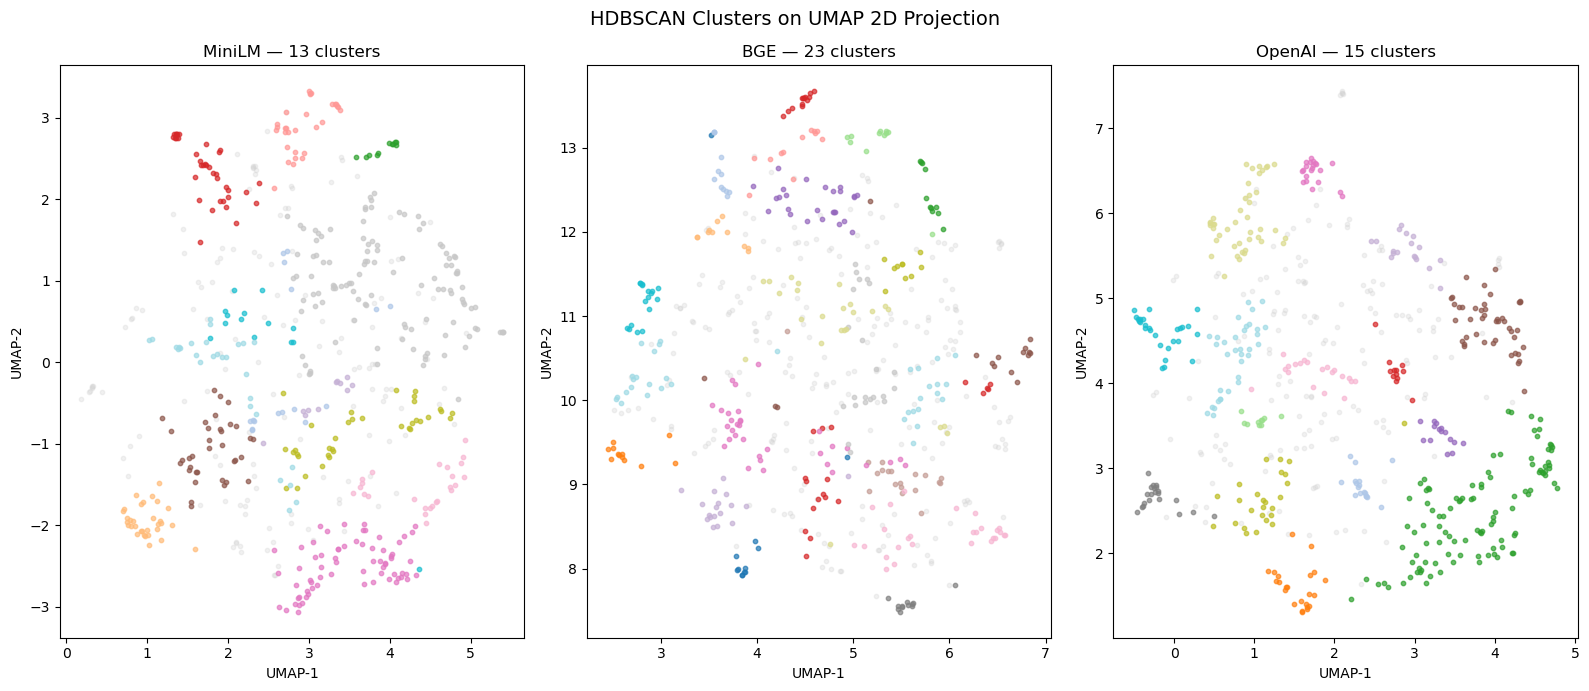

In [66]:
mini_2d = fit_umap(mini_embeddings, n_components=2,  name="MiniLM")
bge_2d  = fit_umap(bge_embeddings,  n_components=2,  name="BGE")
openai_2d = fit_umap(openai_embeddings, n_components=2, name="OpenAI")


def plot_clusters(ax, umap_2d, labels, title):
    unique_labels = sorted(set(labels))
    cmap = plt.cm.get_cmap('tab20', max(len(unique_labels), 1))

    for i, label in enumerate(unique_labels):
        mask  = labels == label
        color = 'lightgrey' if label == -1 else cmap(i)
        alpha = 0.3 if label == -1 else 0.7
        lname = 'Noise' if label == -1 else f'Cluster {label}'
        ax.scatter(umap_2d[mask, 0], umap_2d[mask, 1],
                   s=10, c=[color], alpha=alpha, label=lname)

    ax.set_title(title)
    ax.set_xlabel("UMAP-1")
    ax.set_ylabel("UMAP-2")

fig, axes = plt.subplots(1, 3, figsize=(16, 7))

plot_clusters(axes[0], mini_2d, mini_labels,
              f"MiniLM — {len(set(mini_labels)) - (1 if -1 in mini_labels else 0)} clusters")
plot_clusters(axes[1], bge_2d,  bge_labels,
              f"BGE — {len(set(bge_labels)) - (1 if -1 in bge_labels else 0)} clusters")
plot_clusters(axes[2], openai_2d, openai_labels,
              f"OpenAI — {len(set(openai_labels)) - (1 if -1 in openai_labels else 0)} clusters")

plt.suptitle("HDBSCAN Clusters on UMAP 2D Projection", fontsize=14)
plt.tight_layout()
plt.show()

## Apply c-TF-IDF

In [67]:
def extract_ctfidf_keywords(texts, labels, top_n=10):
    # Group documents by cluster
    cluster_docs = defaultdict(list)
    for text, label in zip(texts, labels):
        if label != -1:
            cluster_docs[label].append(text)

    # Concatenate all docs per cluster into one document
    cluster_ids   = sorted(cluster_docs.keys())
    pseudo_docs   = [" ".join(cluster_docs[cid]) for cid in cluster_ids]

    # Fit TF-IDF on documents
    vectorizer = TfidfVectorizer(
        max_features  = 10000,
        ngram_range   = (1, 2),  # include bigrams
        min_df        = 2,       # ignore very rare terms
        sublinear_tf  = True,    # apply log normalization to TF
    )
    tfidf_matrix = vectorizer.fit_transform(pseudo_docs)  # shape: (n_clusters, vocab)
    vocab        = vectorizer.get_feature_names_out()

    # Extract top_n keywords per cluster
    cluster_keywords = {}
    for i, cid in enumerate(cluster_ids):
        row      = tfidf_matrix[i].toarray().flatten()
        top_idx  = row.argsort()[::-1][:top_n]
        keywords = [(vocab[j], round(row[j], 4)) for j in top_idx]
        cluster_keywords[cid] = keywords

    return cluster_keywords, cluster_docs

mini_keywords, mini_cluster_docs = extract_ctfidf_keywords(texts_strings, mini_labels, top_n=10)
bge_keywords, bge_cluster_docs = extract_ctfidf_keywords(texts_strings, bge_labels,  top_n=10)
openai_keywords, openai_cluster_docs = extract_ctfidf_keywords(texts_strings, openai_labels,  top_n=10)

def display_keywords(cluster_keywords, cluster_docs, name):
    print(f"\n{'='*55}")
    print(f"  {name} — Top 10 Keywords per Cluster")
    print(f"{'='*55}")
    for cid, keywords in cluster_keywords.items():
        n_docs = len(cluster_docs[cid])
        kw_str = ", ".join([kw for kw, _ in keywords])
        print(f"\nCluster {cid:>2} ({n_docs} docs)")
        print(f"  {kw_str}")

display_keywords(mini_keywords, mini_cluster_docs, "MiniLM")
display_keywords(bge_keywords,  bge_cluster_docs,  "BGE")
display_keywords(openai_keywords, openai_cluster_docs, "OpenAI")




  MiniLM — Top 10 Keywords per Cluster

Cluster  0 (16 docs)
  arena, usd, eur, tournament, ostend, vienna, slider, norm, riot, schrager

Cluster  1 (32 docs)
  semantic, cologne, quote, ubs, season season, proposition, palm, christy, byte, quote happy

Cluster  2 (11 docs)
  payroll, data center, harvard, tariff, data analytics, clipboard, level description, inventory management, emission, electricity

Cluster  3 (36 docs)
  gsm, watercolour, android, leh, ota, reply quote, ladakh, leh ladakh, spectrum, spiti

Cluster  4 (30 docs)
  com com, agile, diesel, informative, august september, june july, april may, lace, angular, thanks sharing

Cluster  5 (11 docs)
  orig, sage, cardio, ill, glacier, col, protein, international airport, mural, political social

Cluster  6 (35 docs)
  xbet, freshener, xbet xbet, financi, lieu, devi, agence, air freshener, recruitment, job title

Cluster  7 (68 docs)
  noaa, boring, ashton, silk, cigar, permit, fishery, montgomery, juillet, appraisal

Cluste

## Barcharts of Keywords

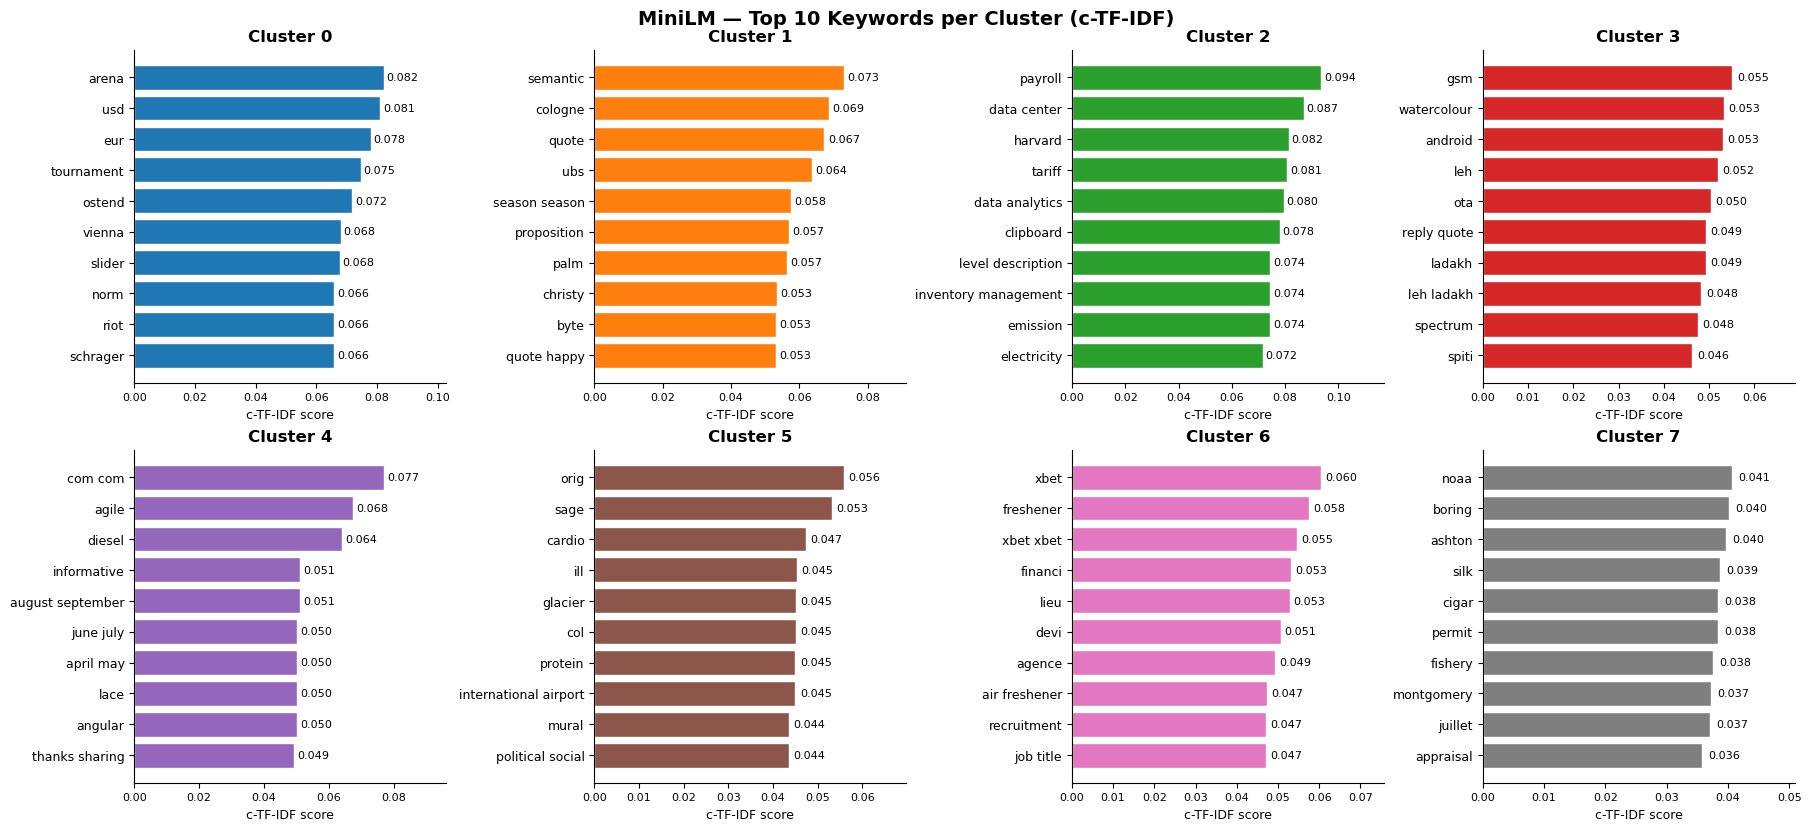

Saved minilm_keywords_barchart.png


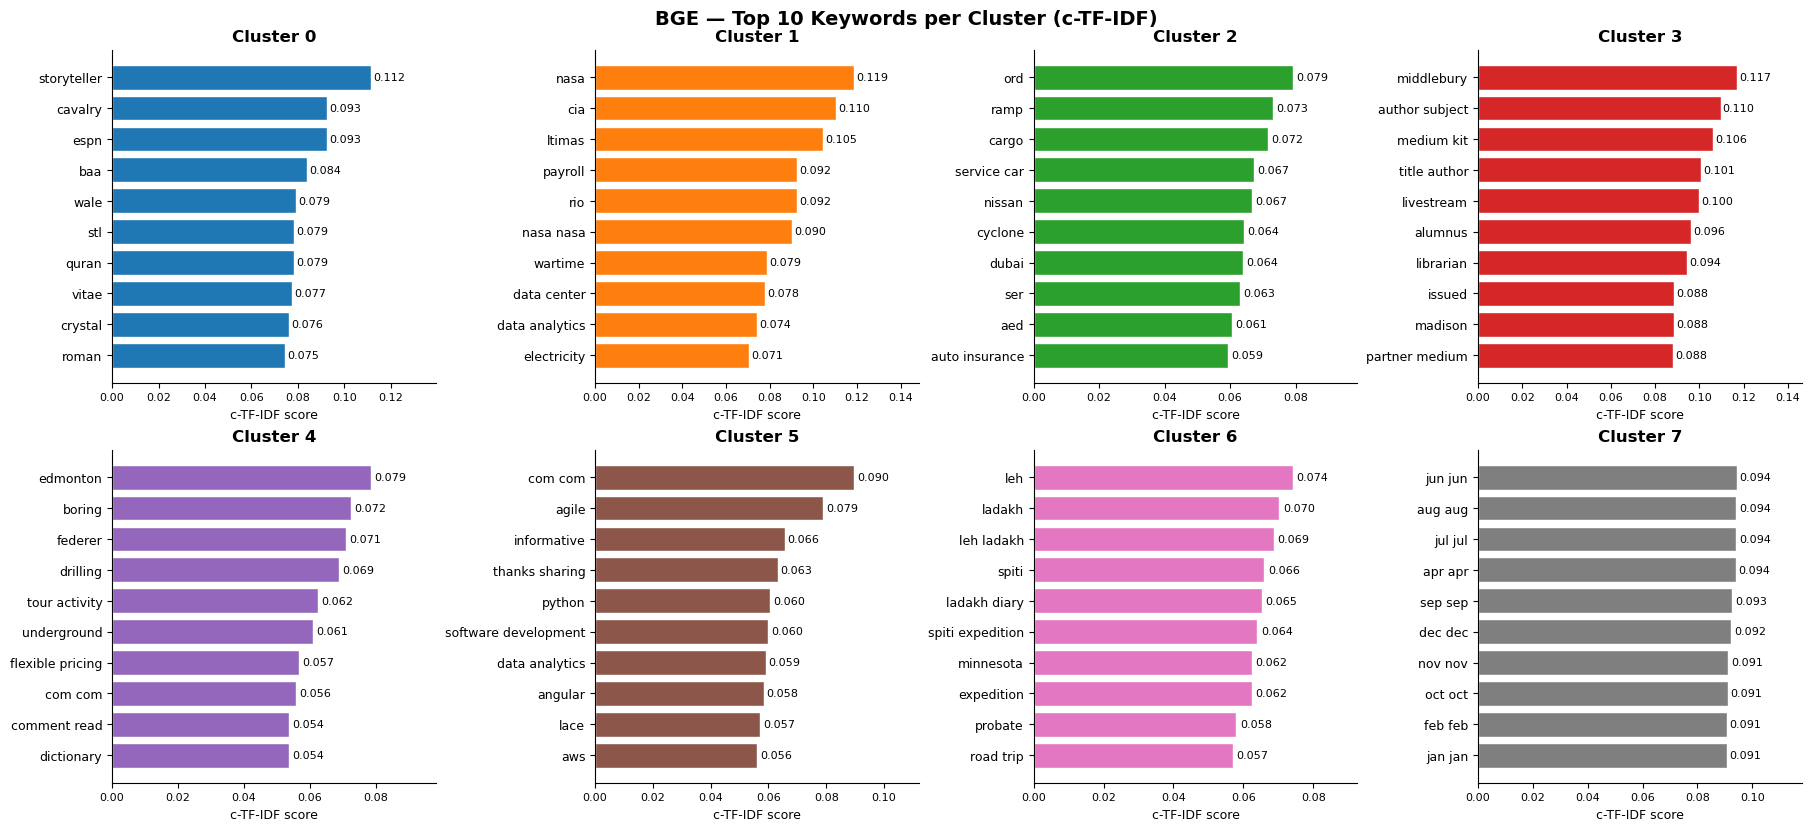

Saved bge_keywords_barchart.png


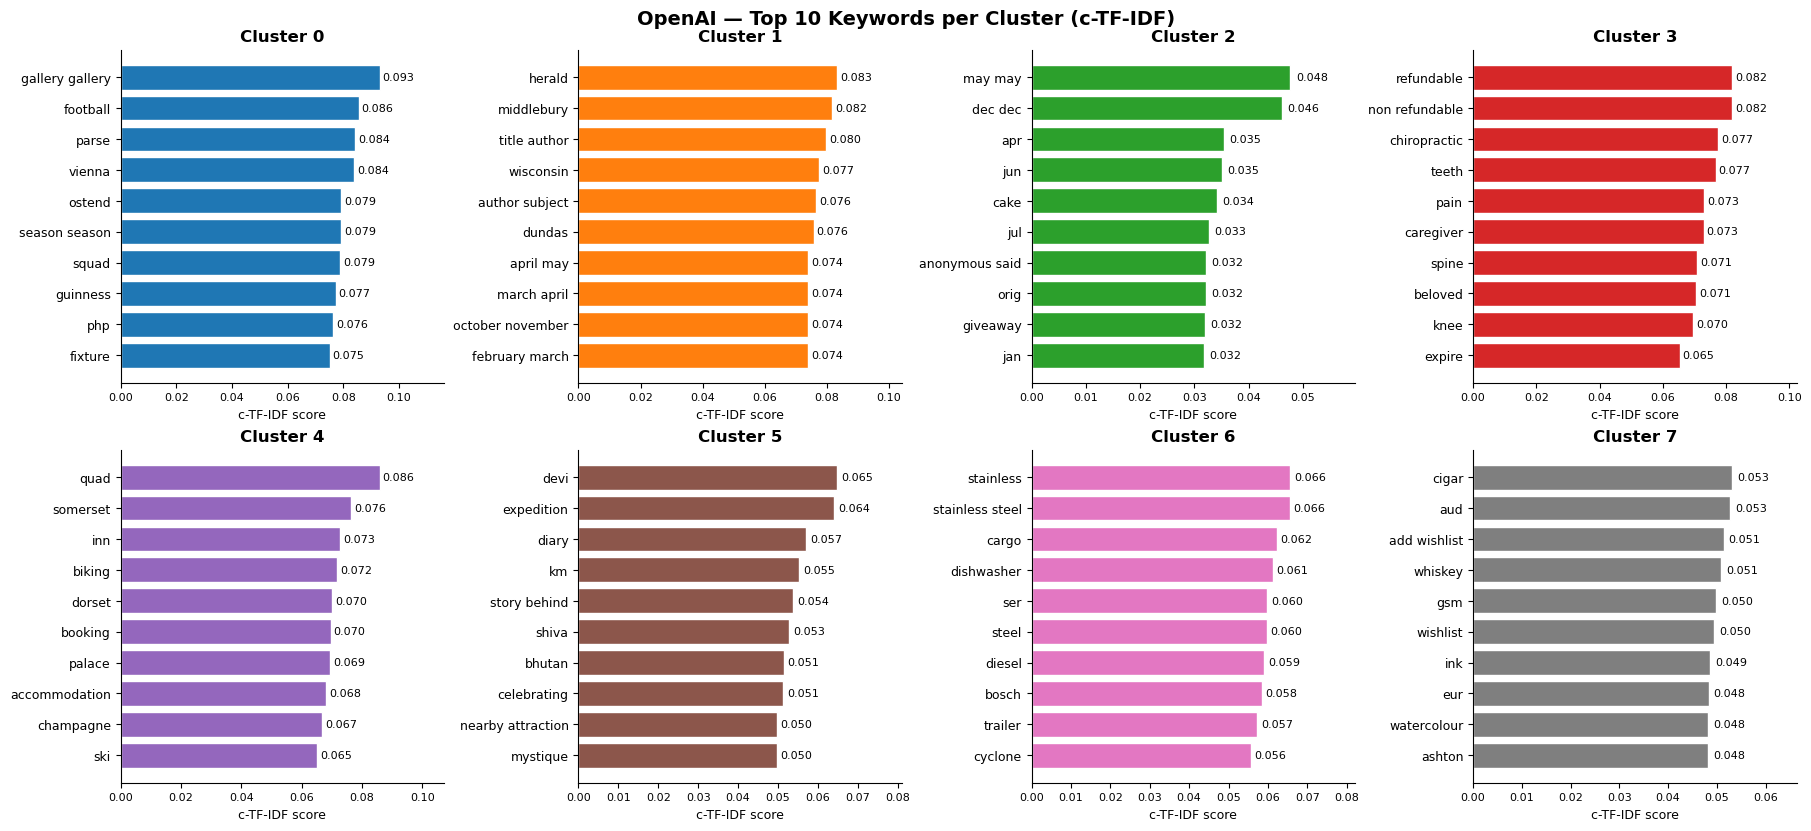

Saved openai_keywords_barchart.png


In [68]:
def plot_keyword_barcharts(cluster_keywords, model_name, top_n=10, max_clusters=8):
    """
    Plot horizontal bar charts showing top keywords for up to 8 clusters.
    cluster_keywords: dict {cluster_id: [(keyword, score), ...]}
    """
    # Pick first max_clusters (skip noise, already excluded)
    cluster_ids = sorted(cluster_keywords.keys())[:max_clusters]
    n_clusters  = len(cluster_ids)

    # Layout: 2 rows x 4 cols
    n_cols = 4
    n_rows = int(np.ceil(n_clusters / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols,
                             figsize=(n_cols * 4.5, n_rows * 4),
                             constrained_layout=True)
    axes = axes.flatten()

    # Color palette — one color per subplot
    colors = list(mcolors.TABLEAU_COLORS.values())

    for i, cid in enumerate(cluster_ids):
        ax       = axes[i]
        keywords = cluster_keywords[cid][:top_n]

        words  = [kw   for kw, _  in keywords][::-1]  # reverse for top-down bar
        scores = [sc   for _,  sc in keywords][::-1]

        bars = ax.barh(words, scores, color=colors[i % len(colors)], edgecolor='white')

        # Add score labels at end of each bar
        for bar, score in zip(bars, scores):
            ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height() / 2,
                    f'{score:.3f}', va='center', ha='left', fontsize=8)

        ax.set_title(f'Cluster {cid}', fontsize=12, fontweight='bold')
        ax.set_xlabel('c-TF-IDF score', fontsize=9)
        ax.tick_params(axis='y', labelsize=9)
        ax.tick_params(axis='x', labelsize=8)
        ax.spines[['top', 'right']].set_visible(False)
        ax.set_xlim(0, max(scores) * 1.25)  # extra space for score labels

    # Hide any unused subplots
    for j in range(n_clusters, len(axes)):
        axes[j].set_visible(False)

    fig.suptitle(f'{model_name} — Top {top_n} Keywords per Cluster (c-TF-IDF)',
                 fontsize=14, fontweight='bold', y=1.02)

    fname = f'{model_name.lower().replace(" ", "_")}_keywords_barchart.png'
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved {fname}")


plot_keyword_barcharts(mini_keywords, model_name="MiniLM", top_n=10, max_clusters=8)
plot_keyword_barcharts(bge_keywords,  model_name="BGE",    top_n=10, max_clusters=8)
plot_keyword_barcharts(openai_keywords, model_name="OpenAI", top_n=10, max_clusters=8)

## ARI and NMI scores

In [75]:
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

def evaluate_clustering(pred_labels, true_labels, model_name):
    mask         = (pred_labels != -1) & ~pd.isna(true_labels)
    pred_clean   = pred_labels[mask]
    true_clean   = true_labels[mask]

    n_clusters   = len(set(pred_labels)) - (1 if -1 in pred_labels else 0)
    noise_pct    = (pred_labels == -1).sum() / len(pred_labels) * 100
    ari          = adjusted_rand_score(true_clean, pred_clean)
    nmi          = normalized_mutual_info_score(true_clean, pred_clean)
    ct           = pd.crosstab(pred_clean, true_clean, normalize='index')
    avg_purity   = ct.max(axis=1).mean()

    return {
        'Model':      model_name,
        'Clusters':   n_clusters,
        'Noise %':    round(noise_pct, 1),
        'ARI':        round(ari, 4),
        'NMI':        round(nmi, 4),
        'Avg Purity': round(avg_purity, 4),
    }

true_labels = df['manual_label_final'].values

rows = [
    evaluate_clustering(mini_labels,   true_labels, 'MiniLM'),
    evaluate_clustering(bge_labels,    true_labels, 'BGE'),
    evaluate_clustering(openai_labels, true_labels, 'OpenAI'),
]

comparison_df = pd.DataFrame(rows).set_index('Model')

def highlight_best(col):
    lower_is_better = col.name == 'Noise %'
    best = col.min() if lower_is_better else col.max()
    return ['border: 2px solid #cc0000' if v == best else '' for v in col]

comparison_df.style \
    .apply(highlight_best) \
    .format({'Noise %': '{:.1f}', 'ARI': '{:.4f}', 'NMI': '{:.4f}', 'Avg Purity': '{:.4f}'}) \
    .set_caption("Clustering Model Comparison") \
    .set_table_styles([{
        'selector': 'caption',
        'props': [('font-size', '14px'), ('font-weight', 'bold'), ('padding', '8px')]
    }])

,Clusters,Noise %,ARI,NMI,Avg Purity
Model,,,,,
MiniLM,13,23.5,0.0046,0.0658,0.3482
BGE,23,37.8,0.0133,0.1352,0.3894
OpenAI,15,26.5,0.1210,0.2411,0.5141


- OpenAI model was the best in ARI, NMI and Average Purity, which are quality metrics. This was somewhat expected for a commercial model.
- MiniLM model was the worst on quality metrics on the other hand, since this is an old light-weighted open source model as a base line.
- BGE model overall worked better than MiniLM for sure, but could not perform as good as OpenAI model.
- However, BGE model had the highest noise with too many clusters. BGE model is over clustering data.
- ARI and NMI scores are low in general for all models, which means that the 8 clusters we provided is not the true structure that the data had. This is very true, since we tried to squeez everything that did not fit into 7 categories into the OTHER category.


## Heatmap

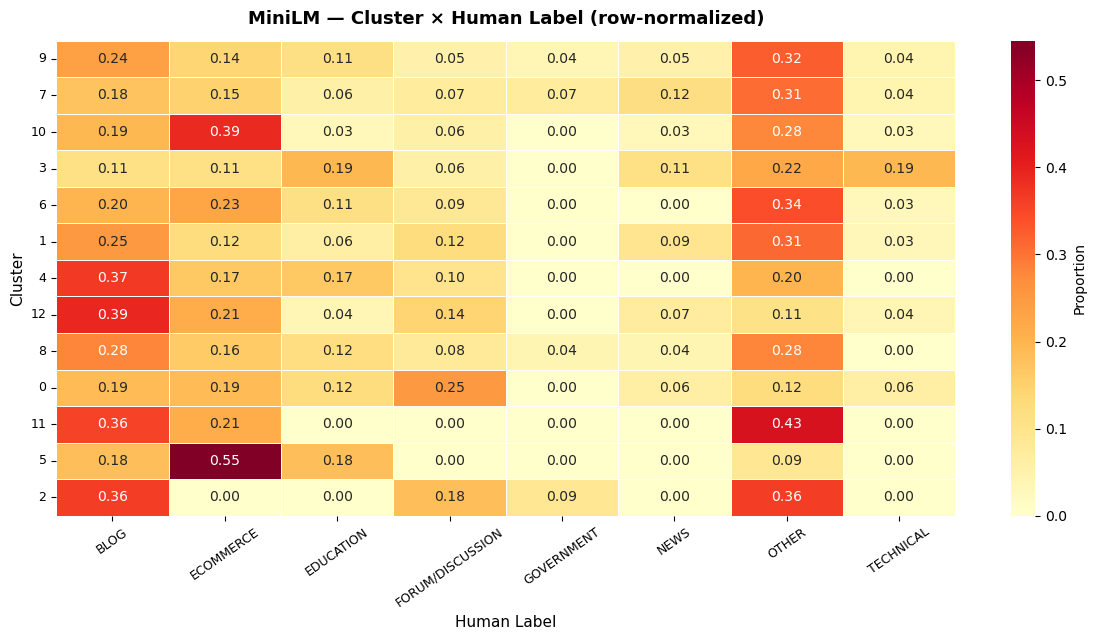

Saved minilm_cluster_heatmap.png


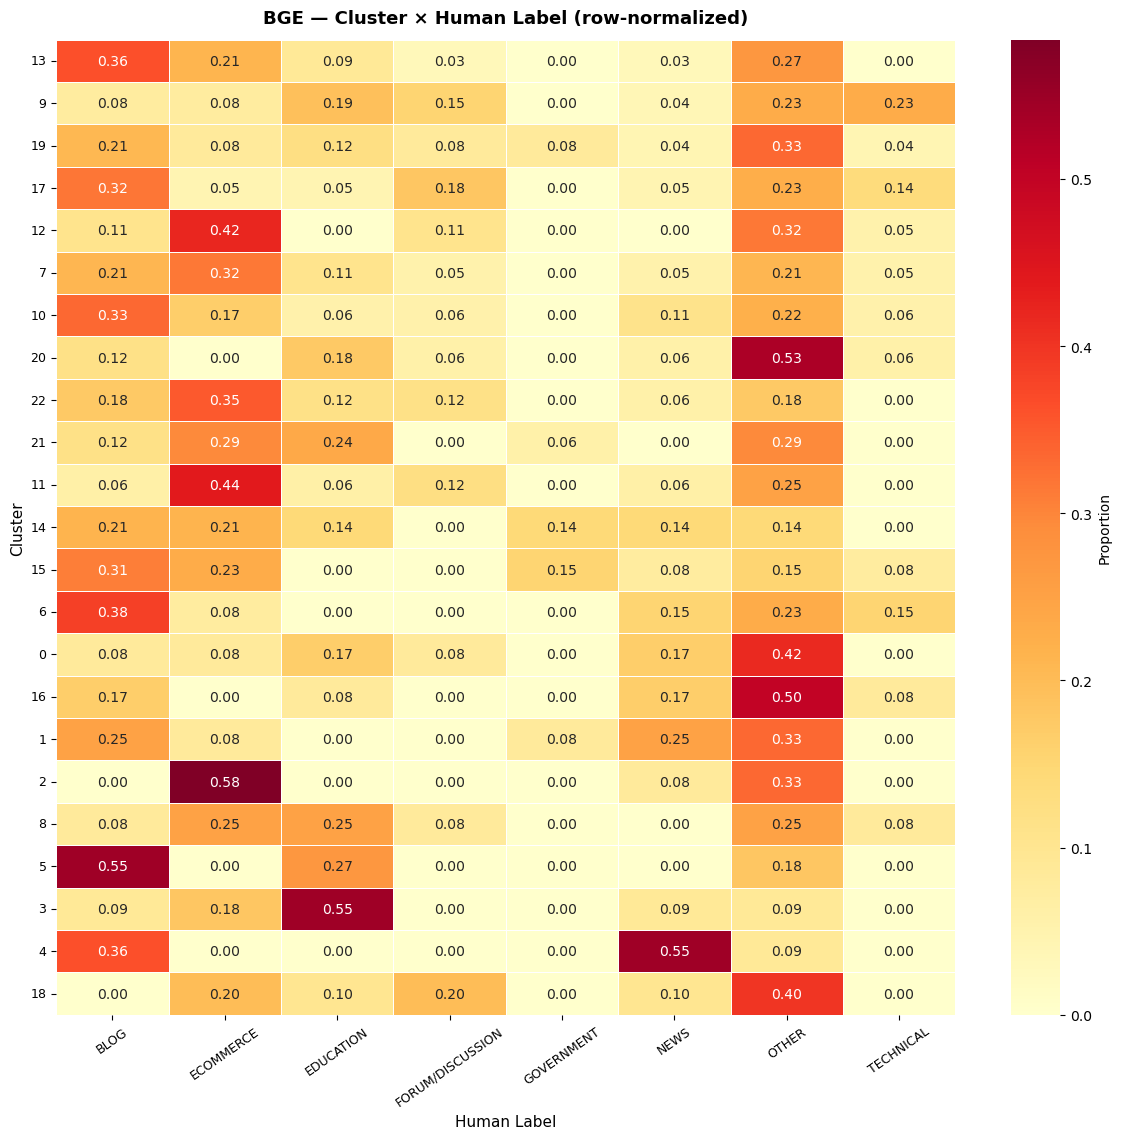

Saved bge_cluster_heatmap.png


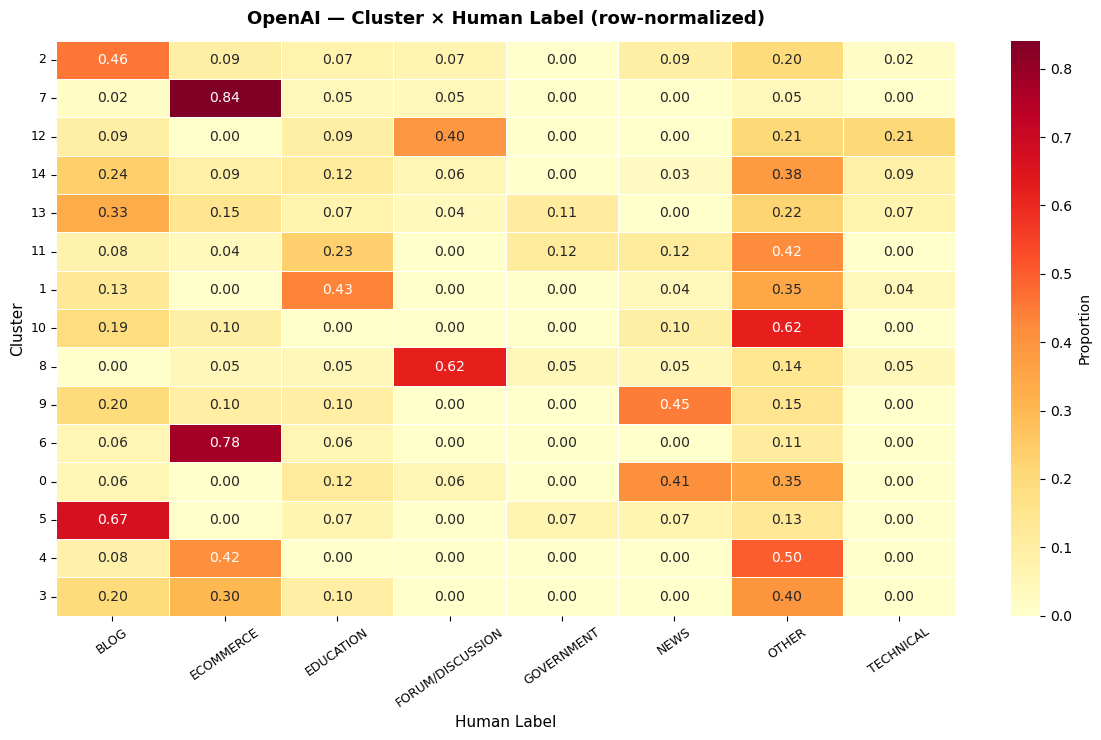

Saved openai_cluster_heatmap.png


In [70]:
def plot_cluster_label_heatmap(pred_labels, true_labels, model_name, normalize='index'):
    """
    normalize:
      'index'  — each ROW (cluster) sums to 1  → "what % of this cluster is each label?"
      'columns'— each COL (label) sums to 1    → "what % of this label lands in each cluster?"
      None     — raw counts
    """
    # Remove noise points
    mask = pred_labels != -1
    pred_clean = pred_labels[mask]
    true_clean = true_labels[mask]

    # Build crosstab
    ct = pd.crosstab(
        pd.Series(pred_clean, name='Cluster'),
        pd.Series(true_clean, name='Human Label'),
        normalize=normalize
    )

    # Sort clusters by size (largest first)
    cluster_sizes = pd.Series(pred_clean).value_counts()
    ct = ct.loc[cluster_sizes.index]

    fig, ax = plt.subplots(figsize=(12, max(5, len(ct) * 0.5)))
    
    sns.heatmap(
        ct,
        annot=True,
        fmt='.2f' if normalize else 'd',
        cmap='YlOrRd',
        linewidths=0.4,
        linecolor='white',
        ax=ax,
        cbar_kws={'label': 'Proportion' if normalize else 'Count'}
    )
    
    norm_label = {'index': '(row-normalized)', 'columns': '(col-normalized)', None: '(raw counts)'}
    ax.set_title(f'{model_name} — Cluster × Human Label {norm_label[normalize]}', 
                 fontsize=13, fontweight='bold', pad=12)
    ax.set_xlabel('Human Label', fontsize=11)
    ax.set_ylabel('Cluster', fontsize=11)
    ax.tick_params(axis='x', rotation=35, labelsize=9)
    ax.tick_params(axis='y', rotation=0,  labelsize=9)
    
    plt.tight_layout()
    fname = f'{model_name.lower()}_cluster_heatmap.png'
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved {fname}")
    
    return ct

# Filter to rows with valid labels first
valid_mask = ~df['manual_label_final'].isna()
true_labels = df.loc[valid_mask, 'manual_label_final'].values
mini_valid  = mini_labels[valid_mask]
bge_valid   = bge_labels[valid_mask]
openai_valid = openai_labels[valid_mask]

mini_ct   = plot_cluster_label_heatmap(mini_valid,   true_labels, "MiniLM")
bge_ct    = plot_cluster_label_heatmap(bge_valid,    true_labels, "BGE")
openai_ct = plot_cluster_label_heatmap(openai_valid, true_labels, "OpenAI")